In [89]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create an empty list that will contain all the rows for the creation of the DataFrame
rows = []
# Iterates over all the files in the folder
for file in Path("archives").rglob("*.json"):
    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Iterates over each dictionary in the list results in the file
    for trial in data["resultats"]:
        # Doesn't take into account the first dictionnary in the list results
        if trial.get("task") != "target":
            continue
        # If no RT, we pass the dictionnary (no interest)
        rt = trial["rt"]
        if not rt:
            continue
        # Get the name of the stimulus
        stimulus=trial["stimulus"]
        # Get the valence of the word
        valence_word = trial["valence"]
        # Get the label of the face ["Attractif","Unattractif"]
        label_face = trial["baseline_attrac"]
        # Get the id of the participant 
        participant_id = trial["participant_id"]
        # Get the response meaning ["Attractif","Non attractif"]
        response_meaning = trial["response_meaning"]
        # Indicates if the label of the face ["Attractif": +,"Non attractif": -] is congruent with the valence of the word
        if valence_word=='neutre':
            congruence='neutre'
        elif (valence_word== "positif" and label_face == "Attractif") or (valence_word == "negatif" and label_face == "Unattractif"):
            congruence = "congruent"
        else:
            congruence = "incongruent"
        # Indicates if the answer is correct or not
        if (label_face == "Attractif" and response_meaning == "Attractif") or (label_face == "Unattractif" and response_meaning == "Non attractif"):
            correct = 1
        else:
            correct = 0
        # Convert response meaning in binary
        if response_meaning=='Attractif':
            response_binary=1
        else:
            response_binary=0
        # Create the row for the DataFrame
        rows.append({
            "id": participant_id,
            "stimulus":stimulus,
            "valence_word":valence_word,
            "label_face":label_face, 
            "congruence": congruence,
            "response_meaning":response_meaning,
            "response_binary":response_binary,
            "correct": correct,
            "rt": rt/1000
        })

# Create the DataFrame
df = pd.DataFrame(rows)
# Display the DataFrame
df

,id,stimulus,valence_word,label_face,congruence,response_meaning,response_binary,correct,rt
0,9at0mps0,face_attrac/WF-233.jpg,positif,Attractif,congruent,Non attractif,0,0,0.223
1,9at0mps0,face_unnattrac/WF-026.jpg,positif,Unattractif,incongruent,Attractif,1,0,0.295
2,9at0mps0,face_unnattrac/BM-219.jpg,negatif,Unattractif,congruent,Non attractif,0,1,0.109
3,9at0mps0,face_unnattrac/WM-215.jpg,neutre,Unattractif,neutre,Attractif,1,0,0.185
4,9at0mps0,face_unnattrac/LM-251.jpg,positif,Unattractif,incongruent,Attractif,1,0,1.067
...,...,...,...,...,...,...,...,...,...
2949,66o3mn1h,face_unnattrac/LM-209.jpg,negatif,Unattractif,congruent,Non attractif,0,1,0.758
2950,66o3mn1h,face_attrac/WF-238.jpg,negatif,Attractif,incongruent,Attractif,1,1,1.361
2951,66o3mn1h,face_attrac/BF-244.jpg,neutre,Attractif,neutre,Non attractif,0,0,0.735
2952,66o3mn1h,face_unnattrac/BM-219.jpg,neutre,Unattractif,neutre,Attractif,1,0,1.164


# Remove outliers

In [90]:
# We take all the rows where the congruence condition is neutral
control = df[df['valence_word'] == 'neutre']
# Pourcentage of correct answer per id
control_pourcentage = control.groupby('id')['correct'].mean()
# Get the index of the id that got a pourcentage of correct answer below 70%
id_outliers = control_pourcentage[control_pourcentage <= .50].index
# If we want to take out some index
id_outliers = id_outliers.append(pd.Index(['imgzntah']))
# Create a DataFrame without outliers
data_without_outliers= df[~df['id'].isin(id_outliers)]
# New variable to dispaly the DataFrame without outliers
dwo_display=data_without_outliers.groupby('id')['correct'].mean().reset_index(name='Percentage good answers')
# Some stats
print(f"Mean percentage of good answers: {dwo_display['Percentage good answers'].mean()}")
print(f"Min percentage of good answers: {dwo_display['Percentage good answers'].min()}")
print(f"Max percentage of good answers: {dwo_display['Percentage good answers'].max()}")
display(dwo_display)

Mean percentage of good answers: 0.7865472172061457
Min percentage of good answers: 0.576271186440678
Max percentage of good answers: 0.9833333333333333


,id,Percentage good answers
0,1v24kyhs,0.894737
1,2jp4ppt2,0.733333
2,3ofn5wde,0.932203
3,4hgpolkf,0.719298
4,66o3mn1h,0.814815
5,6ipwu4mk,0.688889
6,71f898fp,0.610169
7,7eih1i0q,0.576271
8,7re7u25l,0.750000
9,7rngwvq4,0.913793


# Stimulus distribution over conditions

In [91]:
# Group stimulus and valence word, size() get the number of time the stimulus appeared in each condition
# unstack() transform the valence_word columns from 3 rows to 3 colums
stimulus_counts = (data_without_outliers.groupby(['stimulus', 'valence_word']).size().unstack(fill_value=0))

# Compute the mean response binary for each face in each condition
for condition in ["negatif","neutre","positif"] :
    stimulus_counts["response_mean_" + condition] = df[df['valence_word'] == condition].groupby('stimulus')['response_binary'].mean()

# Display statistic of the distribution
stimulus_counts

valence_word,negatif,neutre,positif,response_mean_negatif,response_mean_neutre,response_mean_positif
stimulus,,,,,,
face_attrac/AF-218.jpg,12,21,13,0.692308,0.782609,0.571429
face_attrac/AF-242.jpg,14,15,17,0.444444,0.666667,0.705882
face_attrac/AF-244.jpg,18,10,17,0.473684,0.272727,0.473684
face_attrac/AF-255.jpg,14,18,15,0.866667,0.631579,0.588235
face_attrac/BF-002.jpg,12,19,16,0.692308,0.900000,0.666667
face_attrac/BF-013.jpg,16,10,20,0.882353,0.666667,0.714286
face_attrac/BF-214.jpg,7,21,14,0.444444,0.454545,0.466667
face_attrac/BF-216.jpg,10,13,20,0.600000,0.266667,0.409091
face_attrac/BF-217.jpg,20,15,11,0.652174,0.625000,0.727273


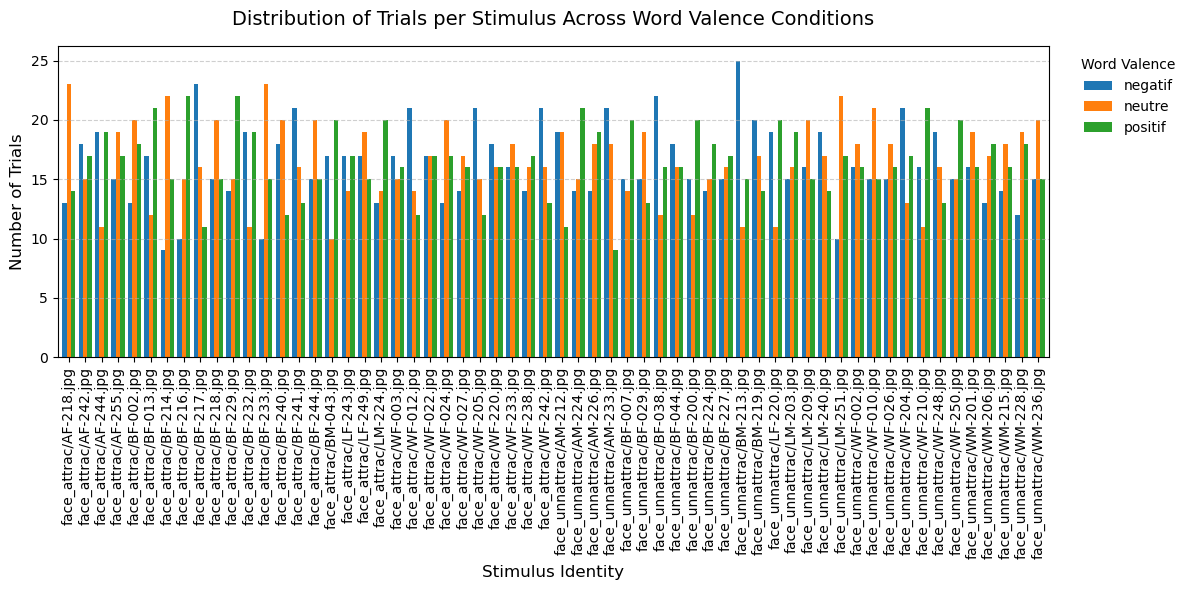

In [92]:
plt.figure(figsize=(12, 6))

# Remove mean response columns (we only want counts)
counts= stimulus_counts.drop(columns=["response_mean_negatif", "response_mean_neutre", "response_mean_positif"],errors="ignore")

# Plot bar chart (distribution of trials per stimulus and valence)
stimulus_counts_histogram.plot(kind='bar', ax=plt.gca(), width=0.8)

# Titles and labels 
plt.title("Distribution of Trials per Stimulus Across Word Valence Conditions", fontsize=14, pad=15)
plt.xlabel("Stimulus Identity", fontsize=12)
plt.ylabel("Number of Trials", fontsize=12)

# Legend
plt.legend(title="Word Valence", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

# Improve readability of the plot bar chat
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 6. Optimize spacing
plt.tight_layout()

plt.show()

In [93]:
from scipy.stats import chisquare

# Get the observed distribution into one vector
observed = counts.values.flatten()
# Compute the expected distribution (uniform)
expected = [observed.mean()] * len(observed)
# Chi-square test
chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

print("GLOBAL TEST")
print(f"Chi2 = {chi2_stat:.3f}, p = {p_value:.5f}")

GLOBAL TEST
Chi2 = 101.338, p = 1.00000


In [94]:
print("\nPER-STIMULUS TEST")

# Create a dictionary that will store the result of chi-2 test per stimulus
results = {}

for stim, row in counts.iterrows():
    # Get the observed distribution
    observed = row.values
    # Compute the expected distribution (uniform)
    expected = [observed.mean()] * len(observed)
    # Chi-square test
    chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)
    # Store the result in the dictionary
    results[stim] = {"chi2": chi2_stat, "p_value": p_value}
    # Print the Chi-2 result
    print(f"{stim} -> Chi2 = {chi2_stat:.3f}, p = {p_value:.5f}")


PER-STIMULUS TEST
face_attrac/AF-218.jpg -> Chi2 = 3.174, p = 0.20455
face_attrac/AF-242.jpg -> Chi2 = 0.304, p = 0.85884
face_attrac/AF-244.jpg -> Chi2 = 2.533, p = 0.28177
face_attrac/AF-255.jpg -> Chi2 = 0.553, p = 0.75836
face_attrac/BF-002.jpg -> Chi2 = 1.574, p = 0.45510
face_attrac/BF-013.jpg -> Chi2 = 3.304, p = 0.19163
face_attrac/BF-214.jpg -> Chi2 = 7.000, p = 0.03020
face_attrac/BF-216.jpg -> Chi2 = 3.674, p = 0.15926
face_attrac/BF-217.jpg -> Chi2 = 2.652, p = 0.26551
face_attrac/BF-218.jpg -> Chi2 = 0.826, p = 0.66163
face_attrac/BF-229.jpg -> Chi2 = 1.064, p = 0.58748
face_attrac/BF-232.jpg -> Chi2 = 3.600, p = 0.16530
face_attrac/BF-233.jpg -> Chi2 = 3.333, p = 0.18888
face_attrac/BF-240.jpg -> Chi2 = 2.130, p = 0.34465
face_attrac/BF-241.jpg -> Chi2 = 1.348, p = 0.50971
face_attrac/BF-244.jpg -> Chi2 = 0.826, p = 0.66163
face_attrac/BM-043.jpg -> Chi2 = 2.279, p = 0.31997
face_attrac/LF-243.jpg -> Chi2 = 0.727, p = 0.69514
face_attrac/LF-249.jpg -> Chi2 = 0.170, p = 0

We can conclude that the distribution is globally not significantly different from a uniform distribution. However, the histogram shows that it is not perfectly uniform in practice. To address this, a stricter pseudo-randomization rule could have been implemented to ensure a perfectly balanced distribution of stimuli across conditions.

It is also important to note that, at the individual stimulus level, the distribution is generally not significantly different from uniform, with the exception of one stimulus ("face_unnattrac/BM-213.jpg"). However, the chi-square values vary considerably across stimuli, indicating inconsistencies in the distribution. This further suggests that, although acceptable overall, the distribution is not perfectly uniform.

# Impact of a non-perfect uniform distribution

Total number of 'attractive' responses by valence condition and face category:


valence_word,negatif,neutre,positif
label_face,,,
Attractif,307.0,323.0,305.0
Unattractif,46.0,51.0,57.0


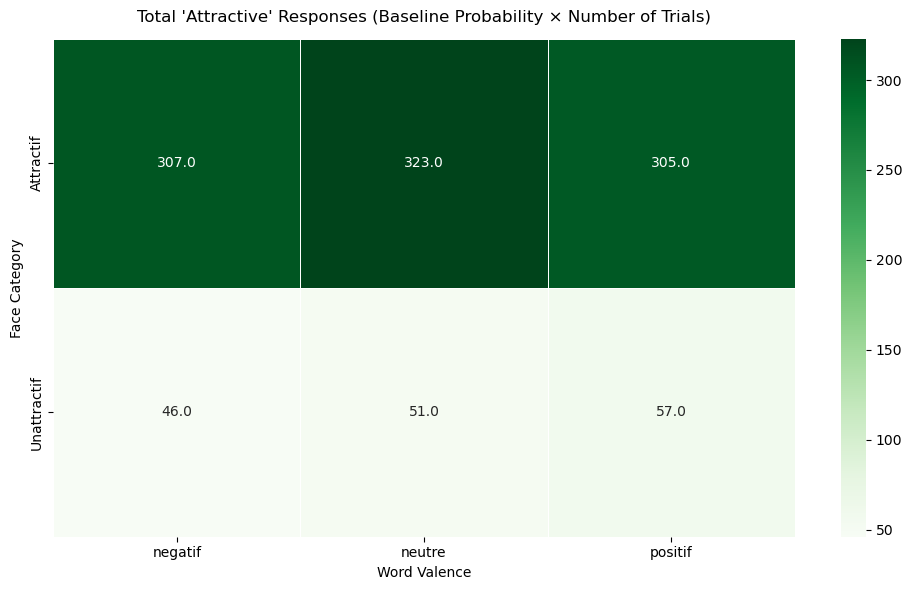

In [98]:
# 1. Count the number of trials (N) for each stimulus × valence × face category
count_map = (
    df
    .groupby(['stimulus', 'valence_word', 'label_face'])
    .size()
    .reset_index(name='n_trials')
)

# 2. Compute mean attractiveness response (probability of judging "attractive")
mean_map = (
    df
    .groupby(['stimulus', 'valence_word', 'label_face'])['response_binary']
    .mean()
    .reset_index(name='mean_attractiveness')
)

# 3. Merge counts and means, then compute total number of "attractive" responses
# (i.e., probability of "attractive" × number of trials)
comparison_df = pd.merge(
    count_map,
    mean_map,
    on=['stimulus', 'valence_word', 'label_face']
)

comparison_df['total_attractive_responses'] = (
    comparison_df['mean_attractiveness'] * comparison_df['n_trials']
)

# 4. Pivot table for easier comparison across valence conditions and face categories
pivot_comparison = comparison_df.pivot_table(
    index='label_face',
    columns='valence_word',
    values='total_attractive_responses',
    aggfunc='sum'
)

print("Total number of 'attractive' responses by valence condition and face category:")
display(pivot_comparison)

# 5. Visualization: heatmap of attractiveness responses
plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot_comparison,
    annot=True,
    fmt='.1f',
    cmap='Greens',
    linewidths=0.5
)

plt.title(
    "Total 'Attractive' Responses (Baseline Probability × Number of Trials)",
    pad=12
)
plt.xlabel("Word Valence")
plt.ylabel("Face Category")

plt.tight_layout()
plt.show()

This analysis aims to evaluate whether word valence influences participants’ tendency to judge faces as attractive. Because the distribution of stimuli is not perfectly uniform and each stimulus has its own baseline level of perceived attractiveness, raw comparisons across conditions may be biased.

To address this, we estimate the expected number of “attractive” responses in each condition under the assumption that valence has no effect. This is done by using the neutral condition to derive a stimulus-specific baseline probability of being judged as attractive, and then weighting this probability by the number of times each stimulus appears in the other conditions.

The resulting values represent the expected response tendency in each condition, accounting for both stimulus difficulty and unequal distribution. Comparing observed responses to these expected values allows us to isolate the effect of word valence on attractiveness judgments.

Bias index (Observed - Expected):


valence_word,negatif,neutre,positif
label_face,,,
Attractif,-5.930017,0.0,-1.955413
Unattractif,-6.006513,0.0,8.719693


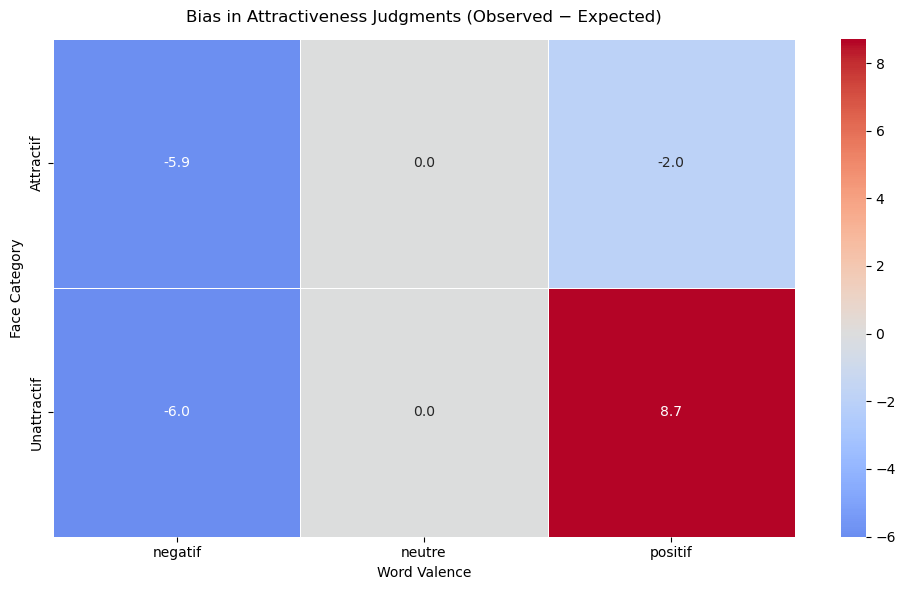

In [99]:
# ----------------------------
# 1. EXPECTED (from neutral baseline)
# ----------------------------

# Neutral baseline per stimulus
baseline = (
    df[df['valence_word'] == 'neutre']
    .groupby('stimulus')['response_binary']
    .mean()
)

# Count trials per condition
counts = (
    df
    .groupby(['stimulus', 'valence_word', 'label_face'])
    .size()
    .reset_index(name='n_trials')
)

# Map baseline to each row
counts['baseline_attractiveness'] = counts['stimulus'].map(baseline)

# Expected number of "attractive" responses
counts['expected_attractive'] = (
    counts['baseline_attractiveness'] * counts['n_trials']
)

# Aggregate expected values
expected_table = counts.pivot_table(
    index='label_face',
    columns='valence_word',
    values='expected_attractive',
    aggfunc='sum'
)

# ----------------------------
# 2. OBSERVED
# ----------------------------

# Total observed "attractive" responses
observed = (
    df
    .groupby(['label_face', 'valence_word'])['response_binary']
    .sum()
    .unstack()
)

# ----------------------------
# 3. BIAS = observed - expected
# ----------------------------

bias = observed - expected_table

print("Bias index (Observed - Expected):")
display(bias)

# ----------------------------
# 4. Visualization
# ----------------------------

plt.figure(figsize=(10, 6))

sns.heatmap(
    bias,
    annot=True,
    fmt='.1f',
    cmap='coolwarm',
    center=0,  # VERY IMPORTANT: 0 = no bias
    linewidths=0.5
)

plt.title("Bias in Attractiveness Judgments (Observed − Expected)", pad=12)
plt.xlabel("Word Valence")
plt.ylabel("Face Category")

plt.tight_layout()
plt.show()

In [104]:
import numpy as np
from scipy.stats import chisquare

for val in observed.columns:
    obs = observed[val].values
    exp = expected_table[val].values

    # remove NaNs
    mask = ~np.isnan(obs) & ~np.isnan(exp)
    obs = obs[mask]
    exp = exp[mask]

    # 🔧 force expected to match observed total
    exp = exp * (obs.sum() / exp.sum())

    chi2, p = chisquare(f_obs=obs, f_exp=exp)

    print(f"{val} → Chi2 = {chi2:.3f}, p = {p:.5f}")

negatif → Chi2 = 0.430, p = 0.51212
neutre → Chi2 = 0.000, p = 1.00000
positif → Chi2 = 1.431, p = 0.23156


# Impact of a new labellisation based on the condition neutral_word